In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tqdm

In [3]:
base = r"D:\JHAhn\files"

In [4]:
df = pd.read_excel(os.path.join(base, "안재혁_8641_Auto_ALPS_index_19-24_main+CTI.xlsx"))
df["PID"] = df["PID"].astype(str).str.zfill(8)
df = df.set_index("PID")
df

,PDI,DDX,Group,Age,Sex_01,Sex,Education (Year),MMSE,CDR,LT_ALL_Dxx_proj,...,LT_CTI_Assoc_Dyy,LT_CTI_Assoc_Dzz,LT_CTI-ALPS index,RT_CTI_Proj_Dxx,RT_CTI_Proj_Dyy,RT_CTI_Proj_Dzz,RT_CTI_Assoc_Dxx,RT_CTI_Assoc_Dyy,RT_CTI_Assoc_Dzz,RT_CTI-ALPS index
PID,,,,,,,,,,,,,,,,,,,,,
02459562,ADEPT54_HCS_NODDI24,NL,0,82,1,F,6.0,27,0.0,0.745723,...,0.472277,0.365113,1.109783,0.520848,0.521945,0.838614,0.467179,0.576006,0.492187,0.974257
00310282,EPT2022AD01_KDKM_NODDI32,AD,2,66,1,F,NaN,23,0.5,0.687428,...,0.183024,0.106396,1.464138,0.065613,0.067988,0.281590,0.176224,0.300066,0.182062,0.967150
00454439,EPT2022AD02_SKM_NODDI32,AD,2,74,0,M,NaN,13,2.0,0.884833,...,0.660463,0.603218,1.030054,0.572164,0.576388,0.822231,0.644952,0.752475,0.651444,0.991272
00461257,EPT2022AD03_KKS_NODDI32,SaMCI,1,74,1,F,12.0,27,0.5,0.688375,...,0.237381,0.136555,1.267073,0.154561,0.157407,0.506764,0.192443,0.356904,0.196123,0.981540
00612238,EPT2022AD05_KIJD_NODDI32,AD,2,83,1,F,NaN,24,1.0,0.687521,...,0.288539,0.223676,1.173859,0.304080,0.295770,0.657524,0.360456,0.467134,0.333783,1.055569
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10412739,MWI_CN79_CYE_NODDI32,SaMCI,1,72,1,F,NaN,28,0.5,0.753935,...,0.200644,0.137980,1.401680,0.060288,0.061287,0.217723,0.152784,0.181179,0.100257,1.318971
10474812,MWI_CN80_LSR_NODDI32,MaMCI,1,78,1,F,NaN,29,0.5,0.602834,...,0.299302,0.205978,1.218601,0.095568,0.095638,0.362974,0.188456,0.319088,0.206177,0.941056
10482577,MWI_CN81_CSH_NODDI32,SaMCI,1,66,0,M,NaN,28,0.5,0.638415,...,0.252498,0.184627,1.198815,0.128332,0.117998,0.345852,0.233705,0.350583,0.250176,0.983328


In [31]:
for column in df.columns:
    print(f"Col name: {column}")
    print(f"Data type: {df[column].dtype}")
    print("Unique values:")
    print(df[column].unique())
    print("-"*50)

Col name: PDI
Data type: object
Unique values:
['ADEPT54_HCS_NODDI24' 'EPT2022AD01_KDKM_NODDI32'
 'EPT2022AD02_SKM_NODDI32' 'EPT2022AD03_KKS_NODDI32'
 'EPT2022AD05_KIJD_NODDI32' 'EPT2022AD063_BPB_NODDI32'
 'EPT2022AD065_CGS_NODDI32' 'EPT2022AD069_LBD_NODDI32'
 'HFC2021AD29_LBD_NODDI32' 'EPT2022AD07_YMY_NODDI32'
 'EPT2022AD070_KSH_NODDI32' 'EPT2022AD10_HSY_NODDI32'
 'EPT2022AD11_PSI_NODDI32' 'EPT2022AD12_SYS_NODDI32'
 'EPT2022AD17_KHS_NODDI32' 'EPT2022AD18_PKW_NODDI32'
 'EPT2022AD19_YJH_NODDI32' 'EPT2022AD20_KYS_NODDI32'
 'EPT2022AD21_KOJ_NODDI32' 'EPT2022AD23_SKSH_NODDI32'
 'EPT2022AD27_KDS_NODDI32' 'EPT2022AD29_LKH_NODDI32'
 'EPT2022AD30_NNO_NODDI32' 'EPT2022AD31_HSB_NODDI32'
 'EPT2022AD34_KMB_NODDI32' 'EPT2022AD38_YYS_NODDI32'
 'EPT2022AD39_LJS_NODDI32' 'EPT2022AD40_RKJ_NODDI32'
 'EPT2022AD41_SIJ_NODDI32' 'EPT2022AD42_HPB_NODDI32'
 'EPT2022AD43_CDH_NODDI32' 'EPT2022AD44_LKJ_NODDI32'
 'EPT2022AD45_CHS_NODDI32' 'EPT2022AD49_PCS_NODDI32'
 'EPT2022AD50_YYH_NODDI32' 'EPT2022AD067_JSO_NODD

In [19]:
## Mapping columns
row_to_alps_col = {
    ("ALL", "LT"): "LT_ALL_ALPS index",
    ("ALL", "RT"): "RT_ALL_ALPS index",
    ("b800", "LT"): "LT_b800_ALPS index",
    ("b800", "RT"): "RT_b800_ALPS index",
    ("b2000", "LT"): "LT_b2000_ALPS index",
    ("b2000", "RT"): "RT_b2000_ALPS index",
    ("CTI", "LT"): "LT_CTI-ALPS index",
    ("CTI", "RT"): "RT_CTI-ALPS index"
}

rows = [
    ("ALL", "DTI-ALPS (ALL)"),
    ("b800", "DTI-ALPS (b=800)"),
    ("b2000", "DTI-ALPS (b=2000)"),
    ("CTI", "CTI-ALPS (ALL)")
]
sides = [("LT", "Left"), ("RT", "Right")]

# region & component
regions = ["Hippocampus"]    # , "Insula"
comps = ["HFC", "EC", "IC"]

# Column naming : Component by 'Side' & 'Regions'
def comp_cols(side, region):
    # 예: side='LT', region='Hippocampus' → ['HFC_LT_Hippocampus', 'EC_LT_Hippocampus', 'IC_LT_Hippocampus']
    return [f"{c}_{side}_{region}" for c in comps]

# y-Axis: column 'Group' --> 0, 1, 2
group_levels = [0, 1, 2]
group_labels = {0: "CN", 1: "MCI", 2: "AD"}

In [26]:
# Plotting
def plot_region_figure(df, region, figsize=(10, 12), dpi=120):
    fig, axes = plt.subplots(nrows=4, ncols=2, figsize=figsize, dpi=dpi, sharex=True, sharey=False)
    fig.suptitle(f"{region}: ALPS indices (HFC/EC/IC overlay)", fontsize=16, y=0.985)

    # x-axis setting (이제 Group이 x축)
    for ax in axes.ravel():
        ax.set_xticks(group_levels)
        ax.set_xticklabels([group_labels[g] for g in group_levels])

    # Each cells: (row: band, col: side)
    for r, (band, row_title) in enumerate(rows):
        for c, (side, side_title) in enumerate(sides):
            ax = axes[r, c]
            ax.set_title(f"{side_title} • {row_title}", fontsize=11)

            # ALPS index cols for y-axis
            alps_col = row_to_alps_col[(band, side)]
            if alps_col not in df.columns:
                ax.text(0.5, 0.5, f"Missing ALPS:\n{alps_col}", ha="center", va="center",
                        transform=ax.transAxes, fontsize=9, alpha=0.7)
                continue

            # mean(ALPS index) by groups
            y_by_group = df.groupby("Group")[alps_col].mean().reindex(group_levels)

            # Same side components: 3-Conductivity cols (HFC/EC/IC)
            cols = comp_cols(side, region)
            missing = [col for col in cols if col not in df.columns]
            if missing:
                ax.text(0.5, 0.5, "Missing comps:\n" + "\n".join(missing), ha="center", va="center",
                        transform=ax.transAxes, fontsize=9, alpha=0.7)

            # 3 Lines for each subplot
            offsets = [-0.06, 0.0, 0.06]  # comp별 시각적 분리 (x축 스텝 내에서 약간만)
            for i, comp in enumerate(comps):
                col = f"{comp}_{side}_{region}"
                if col not in df.columns:
                    continue

                # x: Group(0,1,2) + offset / y: mean(ALPS index) by group
                x_vals = np.array(group_levels, dtype=float) + offsets[i]
                y_vals = y_by_group.values.astype(float)

                ax.plot(x_vals, y_vals, marker="o", label=comp)

            ax.set_xlabel("Group")
            ax.set_ylabel(f"{alps_col}")

            # per-subplot legend 제거 (figure-level로 통합)
            # if r == 0 and c == 1:
            #     ax.legend(title="Component", fontsize=9)

    # ── figure-level legend: 제목 바로 아래 중앙에 1개만 ──
    # 모든 축에서 핸들/라벨 수집 후 중복 제거
    handles, labels = [], []
    seen = set()
    for ax in axes.ravel():
        h, lab = ax.get_legend_handles_labels()
        for hh, ll in zip(h, lab):
            if ll and ll not in seen:
                handles.append(hh); labels.append(ll); seen.add(ll)

    if handles:
        fig.legend(handles, labels,
                   loc='upper center', bbox_to_anchor=(0.5, 0.955),
                   ncol=3, title='Component', fontsize=9)

    # 레이아웃: 제목/범례 공간 확보 (tight_layout 대신 subplots_adjust)
    fig.subplots_adjust(left=0.08, right=0.98, top=0.90, bottom=0.06,
                        hspace=0.35, wspace=0.25)

    return fig, axes

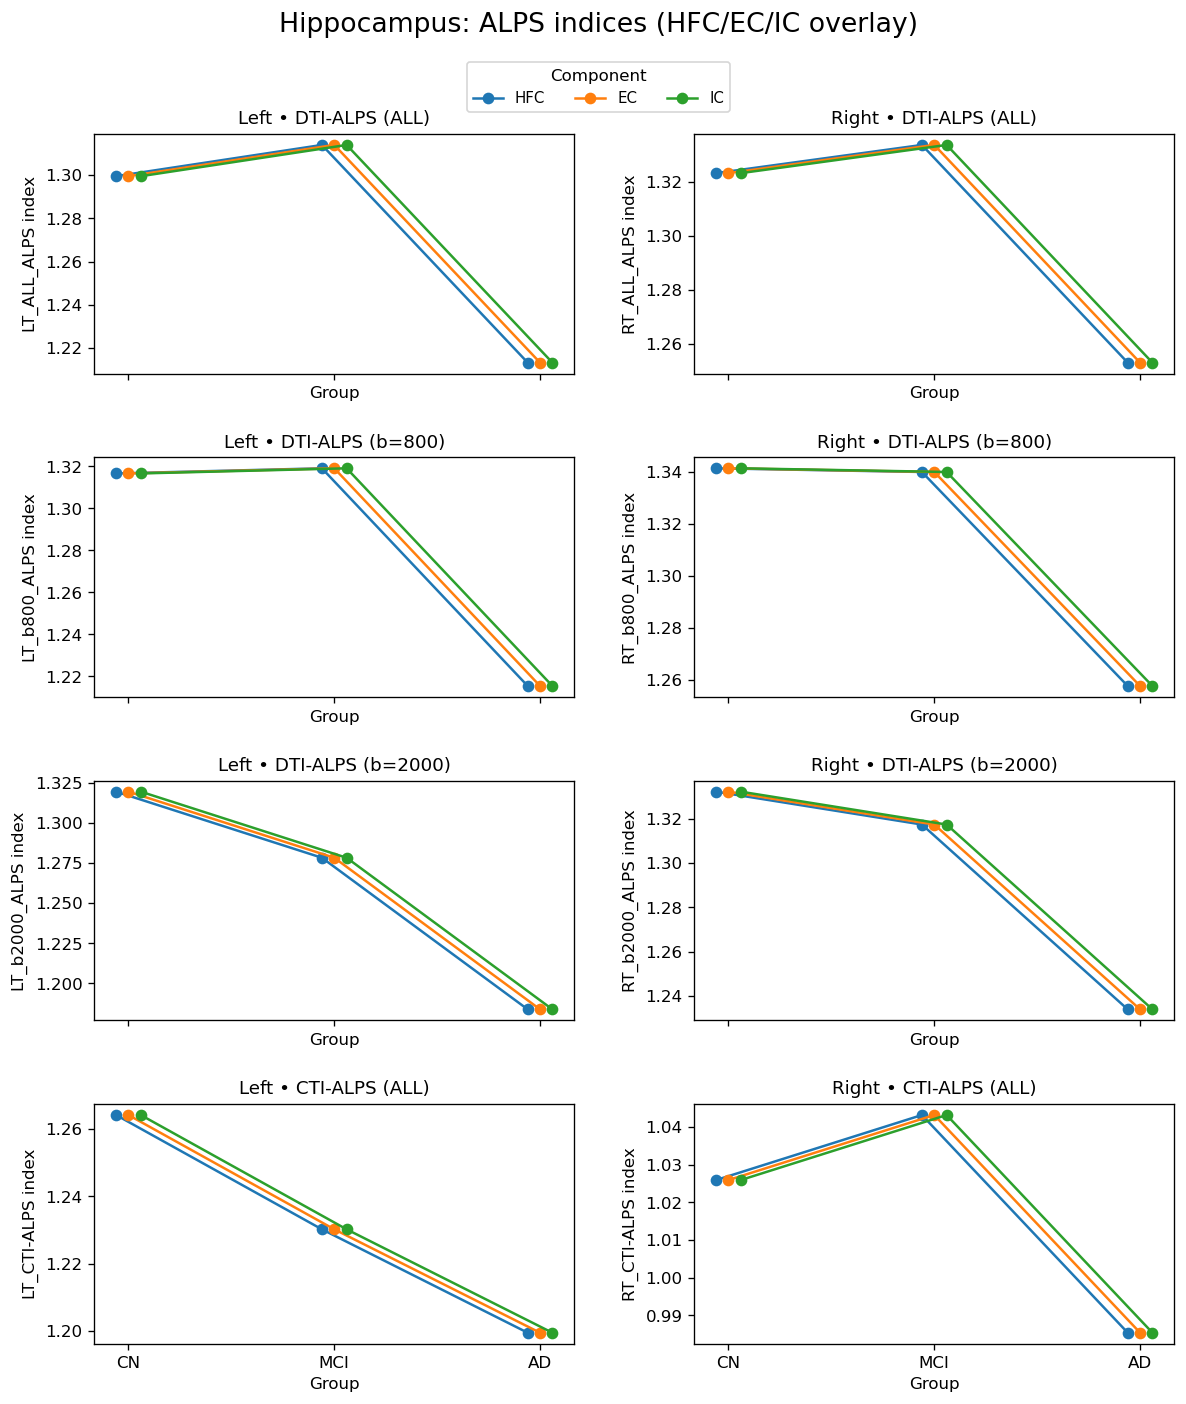

In [27]:
for reg in regions:
    plot_region_figure(df, reg)

plt.show()

In [4]:
map_ddx = {'NL':'CN', 'SaMCI':'*MCI', 'MaMCI':'*MCI', 'AD':'AD'}
dfP = df.copy()
dfP['DDX3'] = dfP['DDX'].map(map_ddx)

group_order = ['AD', '*MCI', 'CN']  # x축 왼→오
row_labels  = ['ALL', 'b=800', 'b=2000', 'CTI']

row_to_alps_col = {
    ('ALL','LT'):   'LT_ALL_ALPS index',
    ('ALL','RT'):   'RT_ALL_ALPS index',
    ('b800','LT'):  'LT_b800_ALPS index',
    ('b800','RT'):  'RT_b800_ALPS index',
    ('b2000','LT'): 'LT_b2000_ALPS index',
    ('b2000','RT'): 'RT_b2000_ALPS index',
    ('CTI','LT'):   'LT_CTI-ALPS index',
    ('CTI','RT'):   'RT_CTI-ALPS index',
}
rows  = [('ALL','DTI-ALPS (ALL)'),
         ('b800','DTI-ALPS (b=800)'),
         ('b2000','DTI-ALPS (b=2000)'),
         ('CTI','CTI-ALPS (ALL)')]
sides = [('LT','LEFT'), ('RT','RIGHT')]

comps   = ['HFC','EC','IC']
# regions = ['Hippocampus','Insula']

def comp_cols(side, region):
    # 예: side='LT', region='Hippocampus'
    return [f'{c}_{side}_{region}' for c in comps]


In [5]:
def plot_region_figure(dfP, region, out=None, figsize=(10, 12), dpi=120):
    """x=DDX3 그룹(AD→*MCI→CN), y=ALPS index(행·열별 선택), 각 서브플롯에 HFC/EC/IC 3라인
       - Figure-level legend (제목 아래 중앙, 한 줄)
       - 상단 행: LT / RT만 표기
       - 각 subplot 내부에 row 제목/ALPS 컬럼명 표기하지 않음
       - y라벨: 왼쪽 열에만 'ALPS index, {row_label}'
    """
    # sharex=False로 모든 subplot에 x tick 라벨 표시
    fig, axes = plt.subplots(4, 2, figsize=figsize, dpi=dpi, sharex=False, sharey=False)

    for r, (band, row_title) in enumerate(rows):
        for c, (side, side_title) in enumerate(sides):
            ax = axes[r, c]
            alps_col = row_to_alps_col[(band, side)]
            if alps_col not in dfP.columns:
                ax.axis('off'); continue

            # 필요한 컬럼만 취합 (ALPS + DDX3 + 컴포넌트 3개)
            needed = [alps_col, 'DDX3'] + comp_cols(side, region)
            sub = dfP[needed].copy()

            # 숫자형 변환 (ALPS와 컴포넌트들), DDX3는 카테고리 유지
            for cc in [alps_col] + comp_cols(side, region):
                sub[cc] = pd.to_numeric(sub[cc], errors='coerce')

            sub = sub.dropna(subset=[alps_col, 'DDX3'])
            if sub.empty:
                ax.axis('off'); continue

            grp    = sub.groupby('DDX3')
            y_mean = grp[alps_col].mean().reindex(group_order).dropna()
            x_pos  = np.arange(len(y_mean))  # 0,1,2

            # x축 tick/라벨: 모든 subplot에 표시
            ax.set_xticks(x_pos)
            ax.set_xticklabels(y_mean.index)
            ax.tick_params(axis='x', labelbottom=True)

            # 보조 세로선
            for xv in x_pos:
                ax.axvline(xv, linestyle='--', linewidth=1, alpha=0.35)

            # 3개 컴포넌트 라인 (요구 스펙상 y=ALPS, 동일 y 공유 → x만 오프셋)
            offsets = [-0.12, 0.0, 0.12]
            for i, comp in enumerate(comps):
                col = f'{comp}_{side}_{region}'
                if col not in sub.columns:
                    continue
                yy = y_mean.values  # y=ALPS 그룹 평균
                ax.plot(x_pos + offsets[i], yy, marker='o', label=comp)

            # 상단 행만 LT/RT 표기, 나머지는 제목 없음
            if r == 0:
                ax.set_title(side_title, fontweight='bold', fontstyle='italic', fontsize=12)
            else:
                ax.set_title("")

            # y축 라벨: 왼쪽 열만 'ALPS index, {row_label}'
            if c == 0:
                ax.set_ylabel(f'ALPS index, {row_labels[r]}')
            else:
                ax.set_ylabel('')

            # 하단 행만 x라벨(문구)
            if r == len(rows) - 1:
                ax.set_xlabel('')
            else:
                ax.set_xlabel('')

            ax.set_xlim(-0.5, len(x_pos) - 0.5)

    # 상단 통합 제목
    fig.suptitle(f'{region}: ALPS–Group plot (AD → *MCI → CN)',
                 fontsize=14, fontweight='bold', y=0.965)

    # figure-level legend (제목 아래 중앙, 한 줄)
    handles, labels = [], []
    seen = set()
    for ax in axes.ravel():
        h, lab = ax.get_legend_handles_labels()
        for hh, ll in zip(h, lab):
            if ll and ll not in seen:
                handles.append(hh); labels.append(ll); seen.add(ll)
    if handles:
        fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.945),
                   ncol=3, title='Components', fontsize=9, frameon=True)

    # 레이아웃(제목/범례 공간 확보)
    fig.subplots_adjust(left=0.12, right=0.98, top=0.88, bottom=0.08,
                        hspace=0.35, wspace=0.25)

    if out:
        pdf_path = os.path.join(out, f'ALPS_group_means_byCond_{region}.pdf')
        fig.savefig(pdf_path)
        print(f'Saved: {pdf_path}')

    plt.show()
    plt.close(fig)

Saved: D:\JHAhn\files\ALPS_group_means_byCond_Hippocampus.pdf


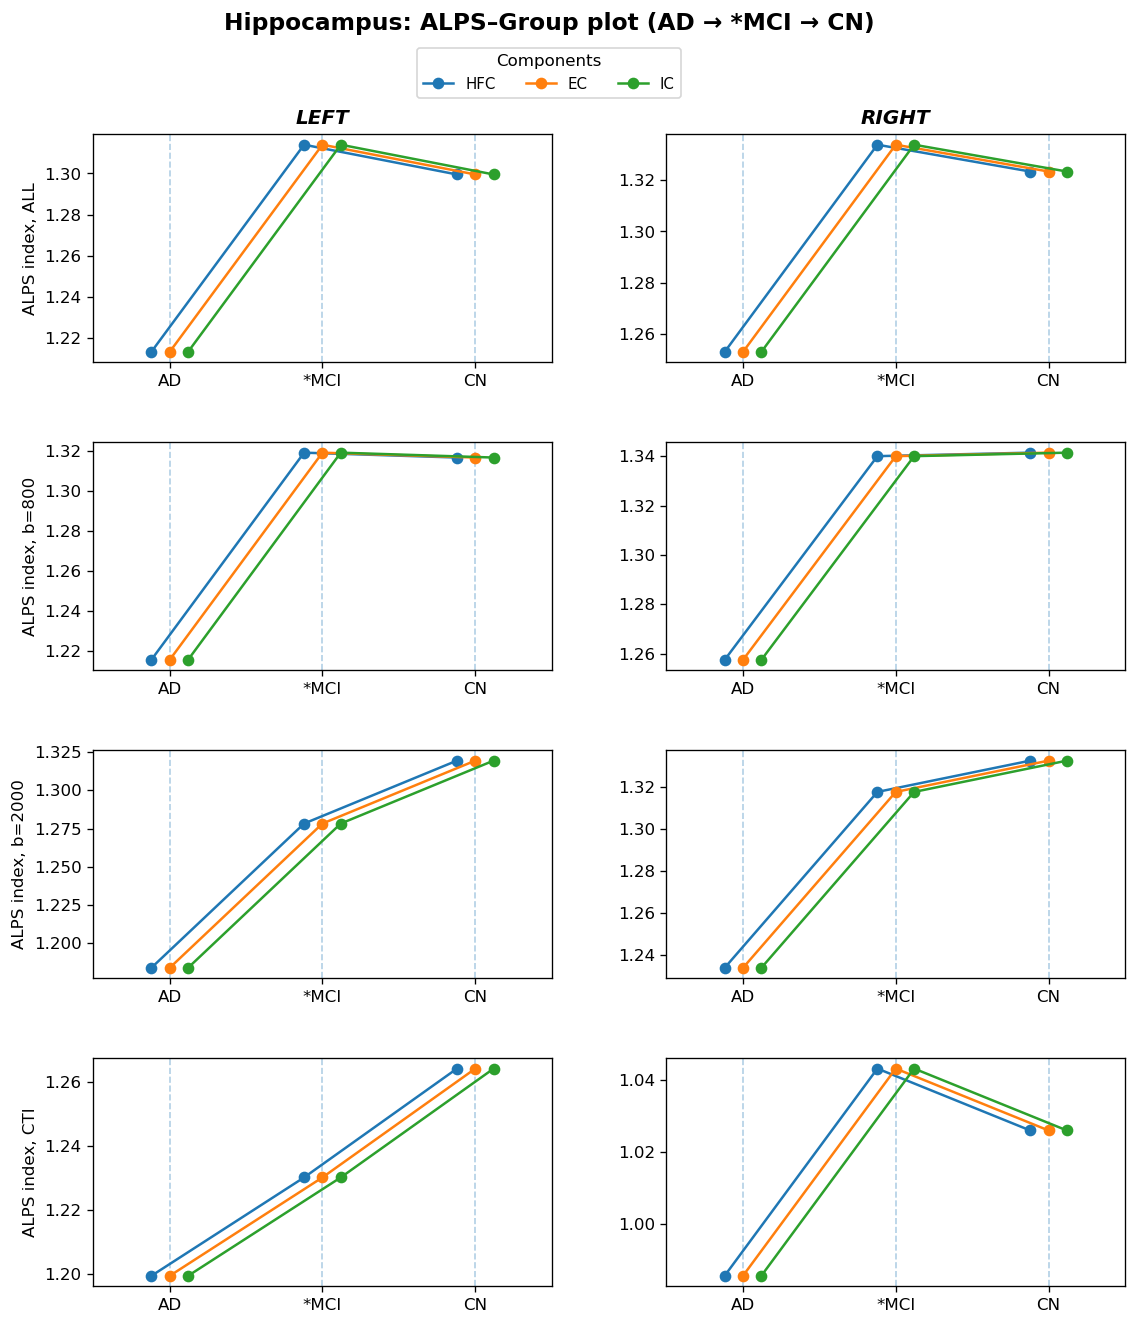

In [7]:
plot_region_figure(dfP, 'Hippocampus', out=base)

Saved: D:\JHAhn\files\ALPS_group_means_byCond_Insula.pdf


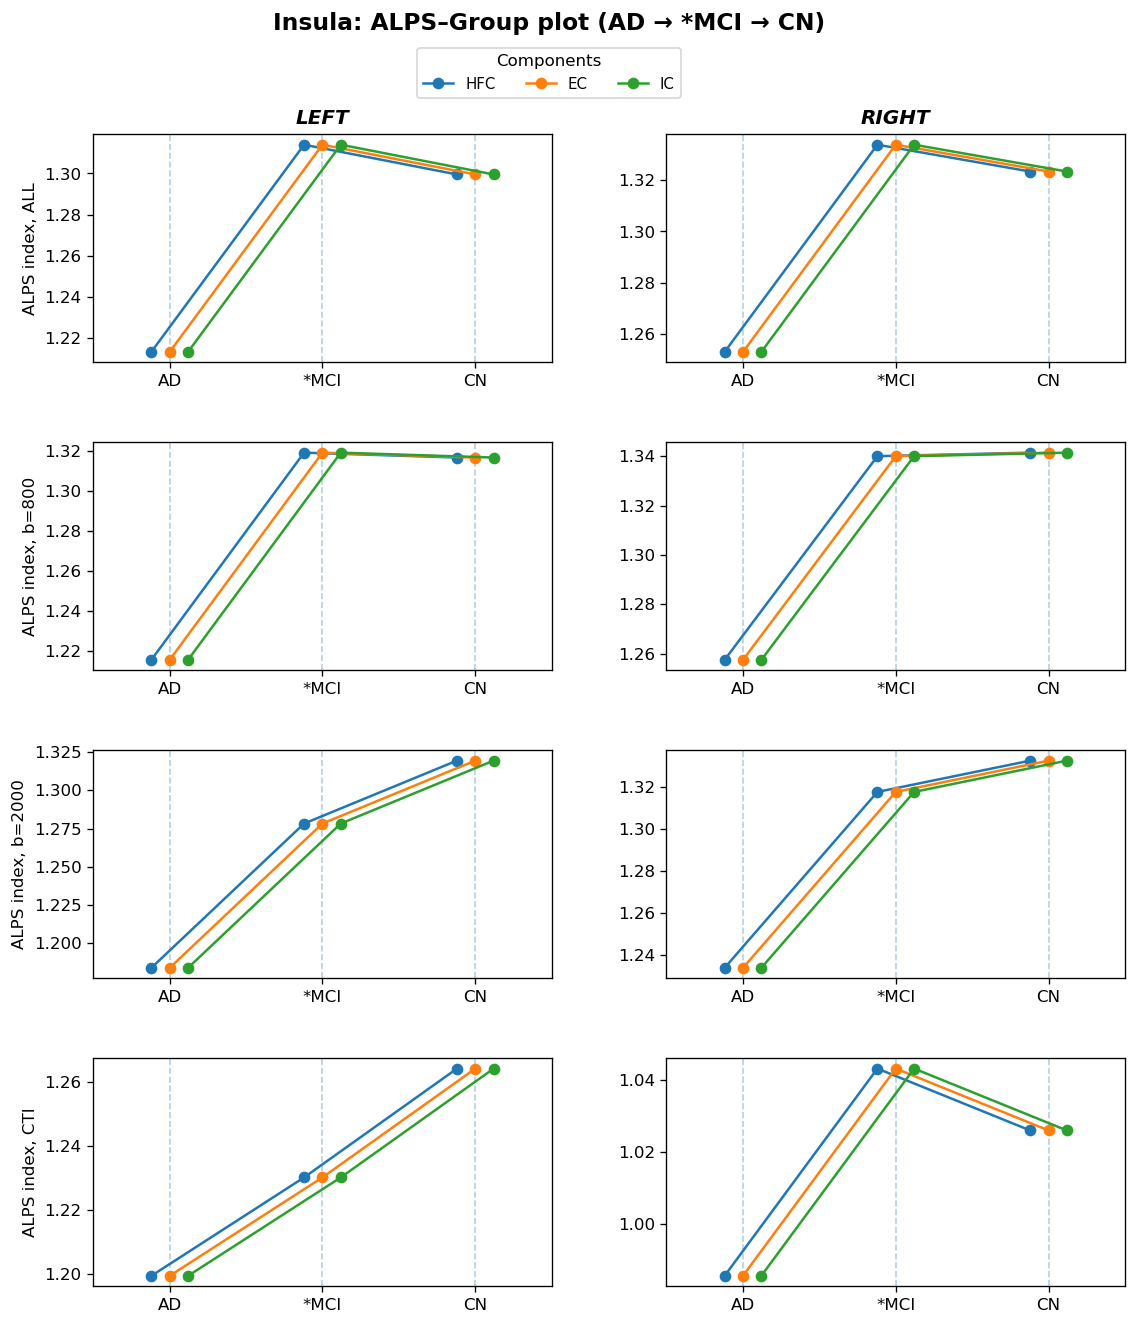

In [6]:
plot_region_figure(dfP, 'Insula', out=base)

In [ ]:
## Plots: ALPS-AGE, ALPS-MMSE

In [ ]:
cti_stats = {
    'Age':  {'LT': (-0.191, '0.055'),  'RT': (-0.220, '0.026')},
    'MMSE': {'LT': ( 0.192, '0.054'),  'RT': ( 0.141, '0.160')},
}
dti_stats = {
    'LT': {
        'Age':  {'ALL': (-0.241, '0.015'), 'b=800': (-0.277, '0.005'), 'b=2000': (-0.223, '0.024')},
        'MMSE': {'ALL': ( 0.212, '0.033'), 'b=800': ( 0.222, '0.025'), 'b=2000': ( 0.214, '0.031')},
    },
    'RT': {
        'Age':  {'ALL': (-0.342, '≤ 0.001'), 'b=800': (-0.365, '≤ 0.001'), 'b=2000': (-0.337, '≤ 0.001')},
        'MMSE': {'ALL': ( 0.174, '0.081'),    'b=800': ( 0.183, '0.067'),    'b=2000': ( 0.211, '0.034')},
    }
}

def _fmt_label(base, r, p):
    """legend용 라벨 포맷터: r은 소수 3자리, p는 '≤ 0.001' 등 특수기호 처리"""
    if isinstance(p, str):
        p_clean = p.strip()
        if p_clean.startswith(('≤', '<', '>')):
            p_text = f"P{p_clean}"         # 예) '≤ 0.001' -> 'P≤ 0.001'
        else:
            p_text = f"P={p_clean}"
    else:
        # 숫자면 0.001 미만은 'P≤ 0.001', 그 외는 'P=0.123'
        try:
            p_val = float(p)
            p_text = "P≤ 0.001" if p_val < 0.001 else f"P={p_val:.3f}"
        except Exception:
            p_text = f"P={p}"

    return f"{base} (r={float(r):.3f}, {p_text})"

In [127]:
# ── 산점도 + 추세선(OLS/빈평균) ───────────────────────────────────────────
def _scatter_with_trend(ax, x, y, label, color=None, s=28, alpha=0.65, lw=2, mode='ols', n_bins=8):
    sub = pd.DataFrame({'x': pd.to_numeric(x, errors='coerce'),
                        'y': pd.to_numeric(y, errors='coerce')}).dropna()
    if sub.empty:
        ax.text(0.5, 0.5, f"No data: {label}", ha='center', va='center',
                transform=ax.transAxes, alpha=0.6)
        return

    # 산점도
    ax.scatter(sub['x'], sub['y'], s=s, alpha=alpha, label=label, color=color)

    if mode == 'ols':
        # 직선(OLS)
        if sub['x'].nunique() < 2:
            x_min, x_max = float(sub['x'].min()), float(sub['x'].max())
            ax.hlines(sub['y'].mean(), x_min, x_max, colors=color, linewidth=lw, alpha=0.9)
            return
        m, b = np.polyfit(sub['x'].values, sub['y'].values, 1)  # y = m x + b
        x_line = np.array([sub['x'].min(), sub['x'].max()], dtype=float)
        y_line = m * x_line + b
        ax.plot(x_line, y_line, color=color, linewidth=lw, alpha=0.9)
    else:
        # 빈 평균선
        x_min, x_max = float(sub['x'].min()), float(sub['x'].max())
        if x_min == x_max:
            return
        bins = np.linspace(x_min, x_max, n_bins + 1)
        cut = pd.cut(sub['x'], bins=bins, include_lowest=True)
        grp = sub.groupby(cut)
        x_mean = grp['x'].mean()
        y_mean = grp['y'].mean()
        mask = x_mean.notna() & y_mean.notna()
        x_line = x_mean[mask].values
        y_line = y_mean[mask].values
        order = np.argsort(x_line)
        ax.plot(x_line[order], y_line[order], linewidth=lw, color=color, alpha=0.9)

# ── 메인 플로팅(좌=Age / 우=MMSE) ─────────────────────────────────────────
def plot_cti_dti_vs_age_mmse(df, figsize=(11, 14), dpi=120, savepath=None, trend='ols', n_bins=8):
    # 숫자형 보정
    for col in ['Age', 'MMSE']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # 색상: 요청대로 DTI 'ALL'은 검정
    colors_cti = {'LT': 'C0', 'RT': 'C1'}
    colors_dti = {'ALL': 'k', 'b=800': 'C1', 'b=2000': 'C2'}

    # 사용할 컬럼
    cti_cols = {'LT': 'LT_CTI-ALPS index', 'RT': 'RT_CTI-ALPS index'}
    dti_cols_LT = {'ALL': 'LT_ALL_ALPS index', 'b=800': 'LT_b800_ALPS index', 'b=2000': 'LT_b2000_ALPS index'}
    dti_cols_RT = {'ALL': 'RT_ALL_ALPS index', 'b=800': 'RT_b800_ALPS index', 'b=2000': 'RT_b2000_ALPS index'}

    fig, axes = plt.subplots(3, 2, figsize=figsize, dpi=dpi, sharex=False, sharey=False)

    # ── Row 0: CTI  ──────────────────────────────────────────────────────
    # [0,0] CTI vs Age (좌)
    ax = axes[0, 0]
    for side, col in cti_cols.items():
        if col in df.columns:
            r, p = cti_stats['Age'][side]
            label = _fmt_label(side, r, p)
            _scatter_with_trend(ax, df['Age'], df[col], label=label, color=colors_cti[side], mode=trend, n_bins=n_bins)
    ax.set_title('CTI-ALPS vs Age', fontweight='bold')
    ax.set_xlabel('Age (years)'); ax.set_ylabel('ALPS index')
    ax.grid(True, alpha=0.25); ax.legend(frameon=True)

    # [0,1] CTI vs MMSE (우)
    ax = axes[0, 1]
    for side, col in cti_cols.items():
        if col in df.columns:
            r, p = cti_stats['MMSE'][side]
            label = _fmt_label(side, r, p)
            _scatter_with_trend(ax, df['MMSE'], df[col], label=label, color=colors_cti[side], mode=trend, n_bins=n_bins)
    ax.set_title('CTI-ALPS vs MMSE', fontweight='bold')
    ax.set_xlabel('MMSE'); ax.set_ylabel('ALPS index')
    ax.grid(True, alpha=0.25); ax.legend(frameon=True)

## Row 1: DTI – LT
    # [1,0] LT DTI vs Age (좌)
    ax = axes[1, 0]
    for tag, col in dti_cols_LT.items():
        if col in df.columns:
            r, p = dti_stats['LT']['Age'][tag]
            label = _fmt_label(tag, r, p)
            _scatter_with_trend(ax, df['Age'], df[col], label=label, color=colors_dti[tag], mode=trend, n_bins=n_bins)
    ax.set_title('LT DTI-ALPS vs Age', fontweight='bold')
    ax.set_xlabel('Age (years)'); ax.set_ylabel('ALPS index')
    ax.grid(True, alpha=0.25); ax.legend(title='LT b-value', frameon=True)

    # [1,1] LT DTI vs MMSE (우)
    ax = axes[1, 1]
    for tag, col in dti_cols_LT.items():
        if col in df.columns:
            r, p = dti_stats['LT']['MMSE'][tag]
            label = _fmt_label(tag, r, p)
            _scatter_with_trend(ax, df['MMSE'], df[col], label=label, color=colors_dti[tag], mode=trend, n_bins=n_bins)
    ax.set_title('LT DTI-ALPS vs MMSE', fontweight='bold')
    ax.set_xlabel('MMSE'); ax.set_ylabel('ALPS index')
    ax.grid(True, alpha=0.25); ax.legend(title='LT b-value', frameon=True)

## Row 2: DTI – RT
    # [2,0] RT DTI vs Age (좌)
    ax = axes[2, 0]
    for tag, col in dti_cols_RT.items():
        if col in df.columns:
            r, p = dti_stats['RT']['Age'][tag]
            label = _fmt_label(tag, r, p)
            _scatter_with_trend(ax, df['Age'], df[col], label=label, color=colors_dti[tag], mode=trend, n_bins=n_bins)
    ax.set_title('RT DTI-ALPS vs Age', fontweight='bold')
    ax.set_xlabel('Age (years)'); ax.set_ylabel('ALPS index')
    ax.grid(True, alpha=0.25); ax.legend(title='RT b-value', frameon=True)

    # [2,1] RT DTI vs MMSE (우)
    ax = axes[2, 1]
    for tag, col in dti_cols_RT.items():
        if col in df.columns:
            r, p = dti_stats['RT']['MMSE'][tag]
            label = _fmt_label(tag, r, p)
            _scatter_with_trend(ax, df['MMSE'], df[col], label=label, color=colors_dti[tag], mode=trend, n_bins=n_bins)
    ax.set_title('RT DTI-ALPS vs MMSE', fontweight='bold')
    ax.set_xlabel('MMSE'); ax.set_ylabel('ALPS index')
    ax.grid(True, alpha=0.25); ax.legend(title='RT b-value', frameon=True)

    fig.suptitle('CTI & DTI ALPS vs Age/MMSE', fontsize=14, y=0.97, fontweight='bold')
    fig.tight_layout(rect=[0, 0, 1, 0.965])

    if savepath:
        fig.savefig(savepath)
        print(f"Saved figure to: {savepath}")

    return fig, axes

Saved figure to: D:\JHAhn\files\ALPS_vs_Age_MMSE.pdf


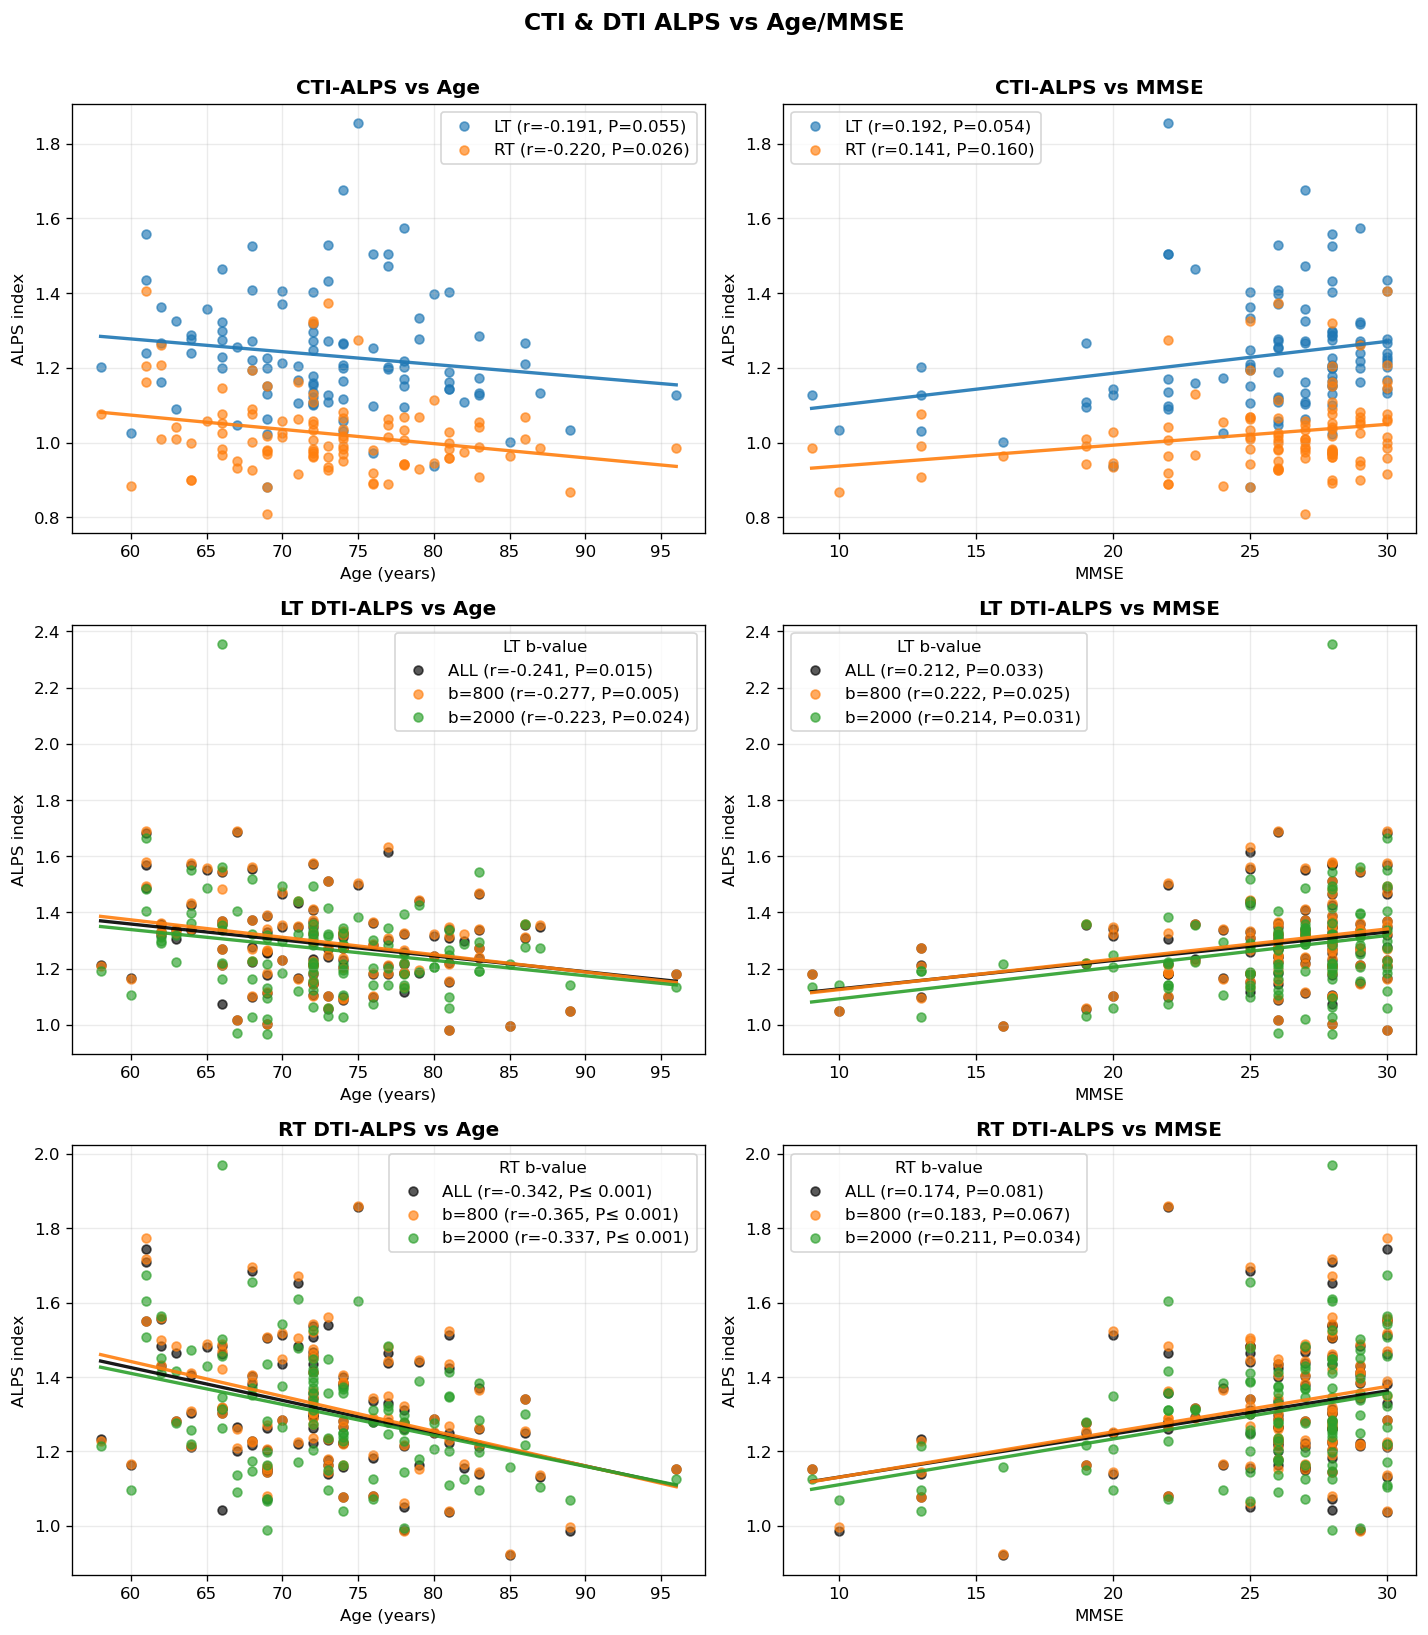

In [128]:
fig, axes = plot_cti_dti_vs_age_mmse(
    df,
    figsize=(12, 14),
    dpi=120,
    trend='ols',   # 'ols' 또는 'bin'
    n_bins=8,      # trend='bin'일 때만 사용
    savepath=os.path.join(base, "ALPS_vs_Age_MMSE.pdf")
)

Saved figure to: D:\JHAhn\files\ALPS_vs_Age_MMSE_bin.pdf


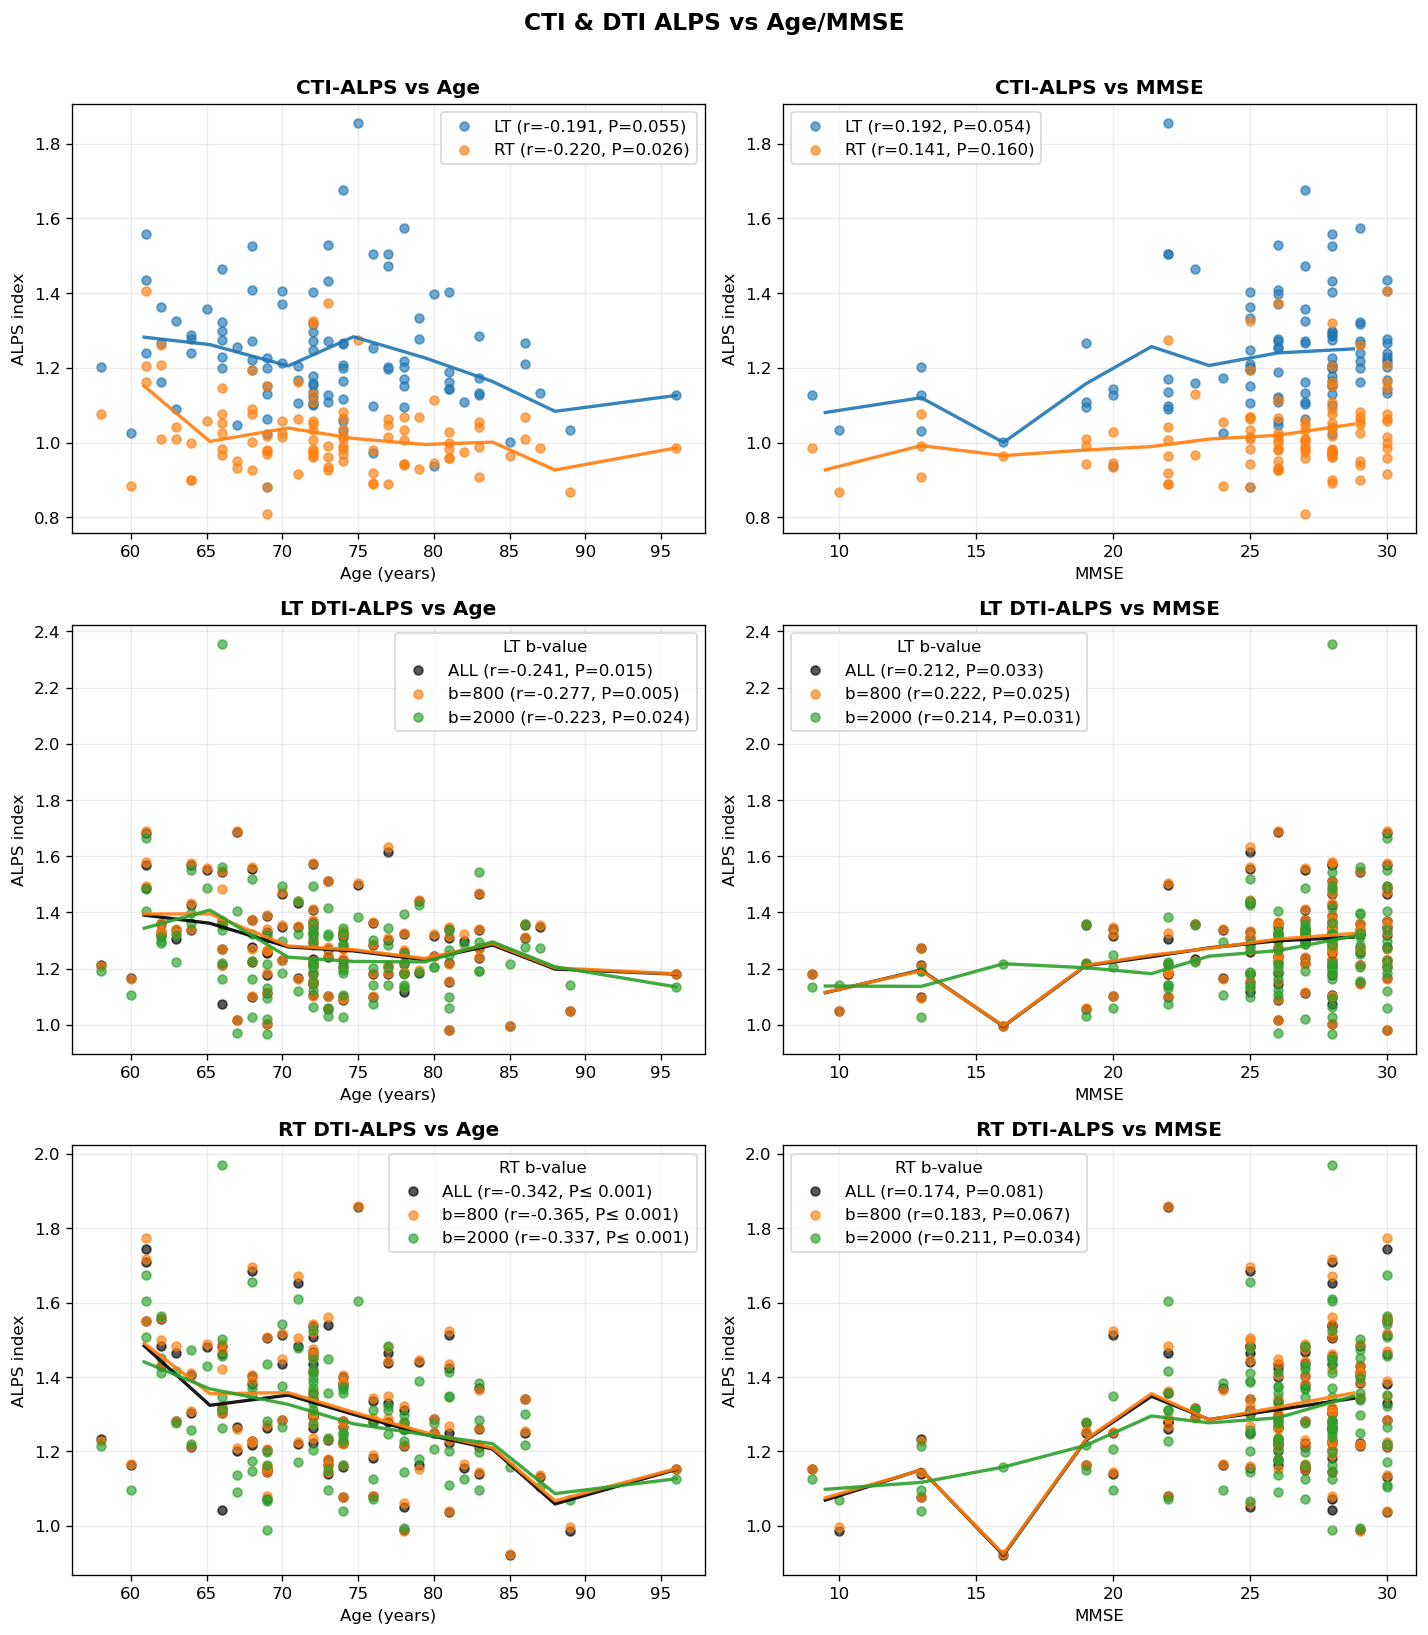

In [129]:
fig, axes = plot_cti_dti_vs_age_mmse(
    df,
    figsize=(12, 14),
    dpi=120,
    trend='bin',   # ols | bin
    n_bins=8,      # trend='bin'일 때만 사용
    savepath=os.path.join(base, "ALPS_vs_Age_MMSE_bin.pdf")
)

In [17]:
dti_cols = [
    'LT_ALL_ALPS index','LT_b800_ALPS index','LT_b2000_ALPS index',
    'RT_ALL_ALPS index','RT_b800_ALPS index','RT_b2000_ALPS index'
]

# 숫자형 강제
for c in dti_cols + ['Age', 'MMSE']:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

# 1) 컬럼별 기본 요약(존재/개수/범위 등)
summary = []
for c in dti_cols:
    exists = c in df.columns
    if not exists:
        summary.append({
            'column': c, 'exists': False, 'n_nonnull': 0, 'n_null': np.nan,
            'n_unique': np.nan, 'min': np.nan, 'max': np.nan, 'mean': np.nan
        })
        continue
    s = df[c]
    summary.append({
        'column': c,
        'exists': True,
        'n_nonnull': int(s.notna().sum()),
        'n_null':   int(s.isna().sum()),
        'n_unique': int(s.nunique(dropna=True)),
        'min':      float(s.min(skipna=True)) if s.notna().any() else np.nan,
        'max':      float(s.max(skipna=True)) if s.notna().any() else np.nan,
        'mean':     float(s.mean(skipna=True)) if s.notna().any() else np.nan,
    })
summary_df = pd.DataFrame(summary).sort_values(['exists','column'], ascending=[False, True]).reset_index(drop=True)

# 2) 플롯용 유효쌍 개수(각 지표 vs Age / vs MMSE 에서 dropna 후 남는 행 수)
pairs = []
for c in dti_cols:
    if c in df.columns:
        n_age  = df[['Age',  c]].dropna().shape[0]
        n_mmse = df[['MMSE', c]].dropna().shape[0]
    else:
        n_age = n_mmse = 0
    pairs.append({'column': c, 'valid_pairs_with_Age': n_age, 'valid_pairs_with_MMSE': n_mmse})
pairs_df = pd.DataFrame(pairs)

# 3) 좌/우 각각에서 3개(bands)가 모두 결측인 케이스 수
left_all_nan  = int(df[['LT_ALL_ALPS index','LT_b800_ALPS index','LT_b2000_ALPS index']].isna().all(axis=1).sum())
right_all_nan = int(df[['RT_ALL_ALPS index','RT_b800_ALPS index','RT_b2000_ALPS index']].isna().all(axis=1).sum())

print("=== DTI-ALPS columns summary ===")
display(summary_df)
print("\n=== Valid pair counts (for plotting) ===")
display(pairs_df)
print(f"\nRows with ALL LT DTI-ALPS missing:  {left_all_nan}")
print(f"Rows with ALL RT DTI-ALPS missing:  {right_all_nan}")

=== DTI-ALPS columns summary ===


,column,exists,n_nonnull,n_null,n_unique,min,max,mean
0,LT_ALL_ALPS index,True,102,0,101,0.981989,1.685871,1.285864
1,LT_b2000_ALPS index,True,102,0,101,0.965916,2.355150,1.268516
2,LT_b800_ALPS index,True,102,0,101,0.980882,1.690331,1.293890
3,RT_ALL_ALPS index,True,102,0,101,0.921116,1.857494,1.311616
4,RT_b2000_ALPS index,True,102,0,101,0.989289,1.970150,1.302288
5,RT_b800_ALPS index,True,102,0,101,0.923851,1.859350,1.320998



=== Valid pair counts (for plotting) ===


,column,valid_pairs_with_Age,valid_pairs_with_MMSE
0,LT_ALL_ALPS index,102,102
1,LT_b800_ALPS index,102,102
2,LT_b2000_ALPS index,102,102
3,RT_ALL_ALPS index,102,102
4,RT_b800_ALPS index,102,102
5,RT_b2000_ALPS index,102,102



Rows with ALL LT DTI-ALPS missing:  0
Rows with ALL RT DTI-ALPS missing:  0


In [108]:
## Ratios <--> Age, MMSE

ratio_specs = [
    ("Insula HFC / Hippocampus Volume",      "R_LT_insulaHFC-HippoVol",  "R_RT_insulaHFC-HippoVol"),
    ("Insula EC / Hippocampus Volume",       "R_LT_insulaEC-HippoVol",   "R_RT_insulaEC-HippoVol"),
    ("Hippocampus HFC / Hippocampus Volume", "R_LT_HippoHFC-HippoVol",   "R_RT_HippoHFC-HippoVol"),
    ("Hippocampus EC / Hippocampus Volume",  "R_LT_HippoEC-HippoVol",    "R_RT_HippoEC-HippoVol"),
    ("Insula HFC / Insula Volume",           "R_LT_InsulaHFC-InsulaVol", "R_RT_InsulaHFC-InsulaVol"),
    ("Insula EC / Insula Volume",            "R_LT_InsulaEC-InsulaVol",  "R_RT_InsulaEC-InsulaVol"),
]

# 2) 제공된 상관 통계 (문자 그대로 사용)
ratio_stats = {
    "Insula HFC / Hippocampus Volume": {
        "Age":  {"LT": ( 0.521, "≤ 0.001"), "RT": ( 0.542, "≤ 0.001")},
        "MMSE": {"LT": (-0.393, "≤ 0.001"), "RT": (-0.405, "≤ 0.001")},
    },
    "Insula EC / Hippocampus Volume": {
        "Age":  {"LT": ( 0.528, "≤ 0.001"), "RT": ( 0.547, "≤ 0.001")},
        "MMSE": {"LT": (-0.417, "≤ 0.001"), "RT": (-0.399, "≤ 0.001")},
    },
    "Hippocampus HFC / Hippocampus Volume": {
        "Age":  {"LT": ( 0.448, "≤ 0.001"), "RT": ( 0.463, "≤ 0.001")},
        "MMSE": {"LT": (-0.274, "0.006"),   "RT": (-0.308, "0.006")},
    },
    "Hippocampus EC / Hippocampus Volume": {
        "Age":  {"LT": ( 0.494, "≤ 0.001"), "RT": ( 0.512, "≤ 0.001")},
        "MMSE": {"LT": (-0.408, "≤ 0.001"), "RT": (-0.468, "≤ 0.001")},
    },
    "Insula HFC / Insula Volume": {
        "Age":  {"LT": ( 0.530, "≤ 0.001"), "RT": ( 0.532, "≤ 0.001")},
        "MMSE": {"LT": (-0.406, "≤ 0.001"), "RT": (-0.442, "≤ 0.001")},
    },
    "Insula EC / Insula Volume": {
        "Age":  {"LT": ( 0.523, "≤ 0.001"), "RT": ( 0.539, "≤ 0.001")},
        "MMSE": {"LT": (-0.432, "≤ 0.001"), "RT": (-0.435, "≤ 0.001")},
    },
}

def _fmt_label(base, r, p):
    """legend용 라벨 포맷터: r은 소수 3자리, p는 '≤ 0.001' 등 특수기호 처리"""
    if isinstance(p, str):
        p_clean = p.strip()
        if p_clean.startswith(('≤', '<', '>')):
            p_text = f"P{p_clean}"         # 예) '≤ 0.001' -> 'P≤ 0.001'
        else:
            p_text = f"P={p_clean}"
    else:
        # 숫자면 0.001 미만은 'P≤ 0.001', 그 외는 'P=0.123'
        try:
            p_val = float(p)
            p_text = "P≤ 0.001" if p_val < 0.001 else f"P={p_val:.3f}"
        except Exception:
            p_text = f"P={p}"

    return f"{base} (r={float(r):.3f}, {p_text})"

In [119]:
def plot_ratio_age_mmse_overlay(df, figsize=(12, 24), dpi=120, savepath=None):
    # 숫자형 보정
    for col in ['Age', 'MMSE']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    colors_side = {'LT': 'C0', 'RT': 'C1'}

    n_rows = len(ratio_specs)
    fig, axes = plt.subplots(nrows=n_rows, ncols=2, figsize=figsize, dpi=dpi,
                             sharex=False, sharey=False)

    # ── 메인 루프 ────────────────────────────────────────────────────────
    for r, (title, lt_col, rt_col) in enumerate(ratio_specs):
        # 행 공통 y범위
        yvals = []
        for c_name in (lt_col, rt_col):
            if c_name in df.columns:
                yvals.append(pd.to_numeric(df[c_name], errors='coerce'))
        y_all = pd.concat(yvals, axis=0).dropna() if yvals else pd.Series(dtype=float)
        ylim_row = None
        if not y_all.empty:
            y_min, y_max = float(y_all.min()), float(y_all.max())
            pad = 0.05 * (y_max - y_min if y_max > y_min else 1.0)
            ylim_row = (y_min - pad, y_max + pad)

        # 두 열: 0=Age, 1=MMSE (각 축에 LT·RT를 함께)
        for c, xvar in enumerate(('Age', 'MMSE')):
            ax = axes[r, c]

            # LT
            if lt_col in df.columns:
                r_val, p_val = ratio_stats[title][xvar]['LT']
                label = _fmt_label('LT', r_val, p_val)
                _scatter_with_trend(ax, df[xvar], df[lt_col], label=label, color=colors_side['LT'])
            else:
                ax.text(0.5, 0.5, f"Missing: {lt_col}", ha='center', va='center',
                        transform=ax.transAxes, alpha=0.7)

            # RT
            if rt_col in df.columns:
                r_val, p_val = ratio_stats[title][xvar]['RT']
                label = _fmt_label('RT', r_val, p_val)
                _scatter_with_trend(ax, df[xvar], df[rt_col], label=label, color=colors_side['RT'])
            else:
                ax.text(0.5, 0.4, f"Missing: {rt_col}", ha='center', va='center',
                        transform=ax.transAxes, alpha=0.7)

            # ── subplot 제목: 가운데 정렬, 1pt 크게, 여백 확대
            ax.set_title(title, loc='center', fontsize=12, pad=10)

            ax.grid(True, alpha=0.25)
            if ylim_row:
                ax.set_ylim(ylim_row)

            # 축 라벨: 좌열만 y라벨, x라벨은 모두 제거(열 헤더만 사용)
            if c == 0:
                ax.set_ylabel('Ratio index')
            else:
                ax.set_ylabel('')
            ax.set_xlabel('')  # ← 하단의 작은 Age/MMSE 라벨 완전 제거

            ax.legend(frameon=True, fontsize=9, loc='upper right')

    # ── 레이아웃: subplot 높이 키우고, 행 간격(hspace) 줄임 ────────────────
    fig.subplots_adjust(left=0.065, right=0.975, top=0.92, bottom=0.06,
                        hspace=0.4, wspace=0.15)

    # 열 제목 'Age' / 'MMSE'를 축 밖(fig-level)에 배치(겹침 방지)
    posL = axes[0, 0].get_position()
    posR = axes[0, 1].get_position()
    ycol = max(posL.y1, posR.y1) + 0.02  # 축 위 살짝
    fig.text((posL.x0 + posL.x1) / 2, ycol, 'Age',
             ha='center', va='bottom', fontsize=13, fontweight='bold', fontstyle='italic')
    fig.text((posR.x0 + posR.x1) / 2, ycol, 'MMSE',
             ha='center', va='bottom', fontsize=13, fontweight='bold', fontstyle='italic')

    # 전체 제목
    fig.suptitle('Ratio indices vs Age (left) and MMSE (right)',
                 fontsize=14, fontweight='bold', y=0.98)

    if savepath:
        fig.savefig(savepath)
        print(f"Saved: {savepath}")

    return fig, axes

Saved: D:\JHAhn\files\Ratio_Age_MMSE_overlay.pdf


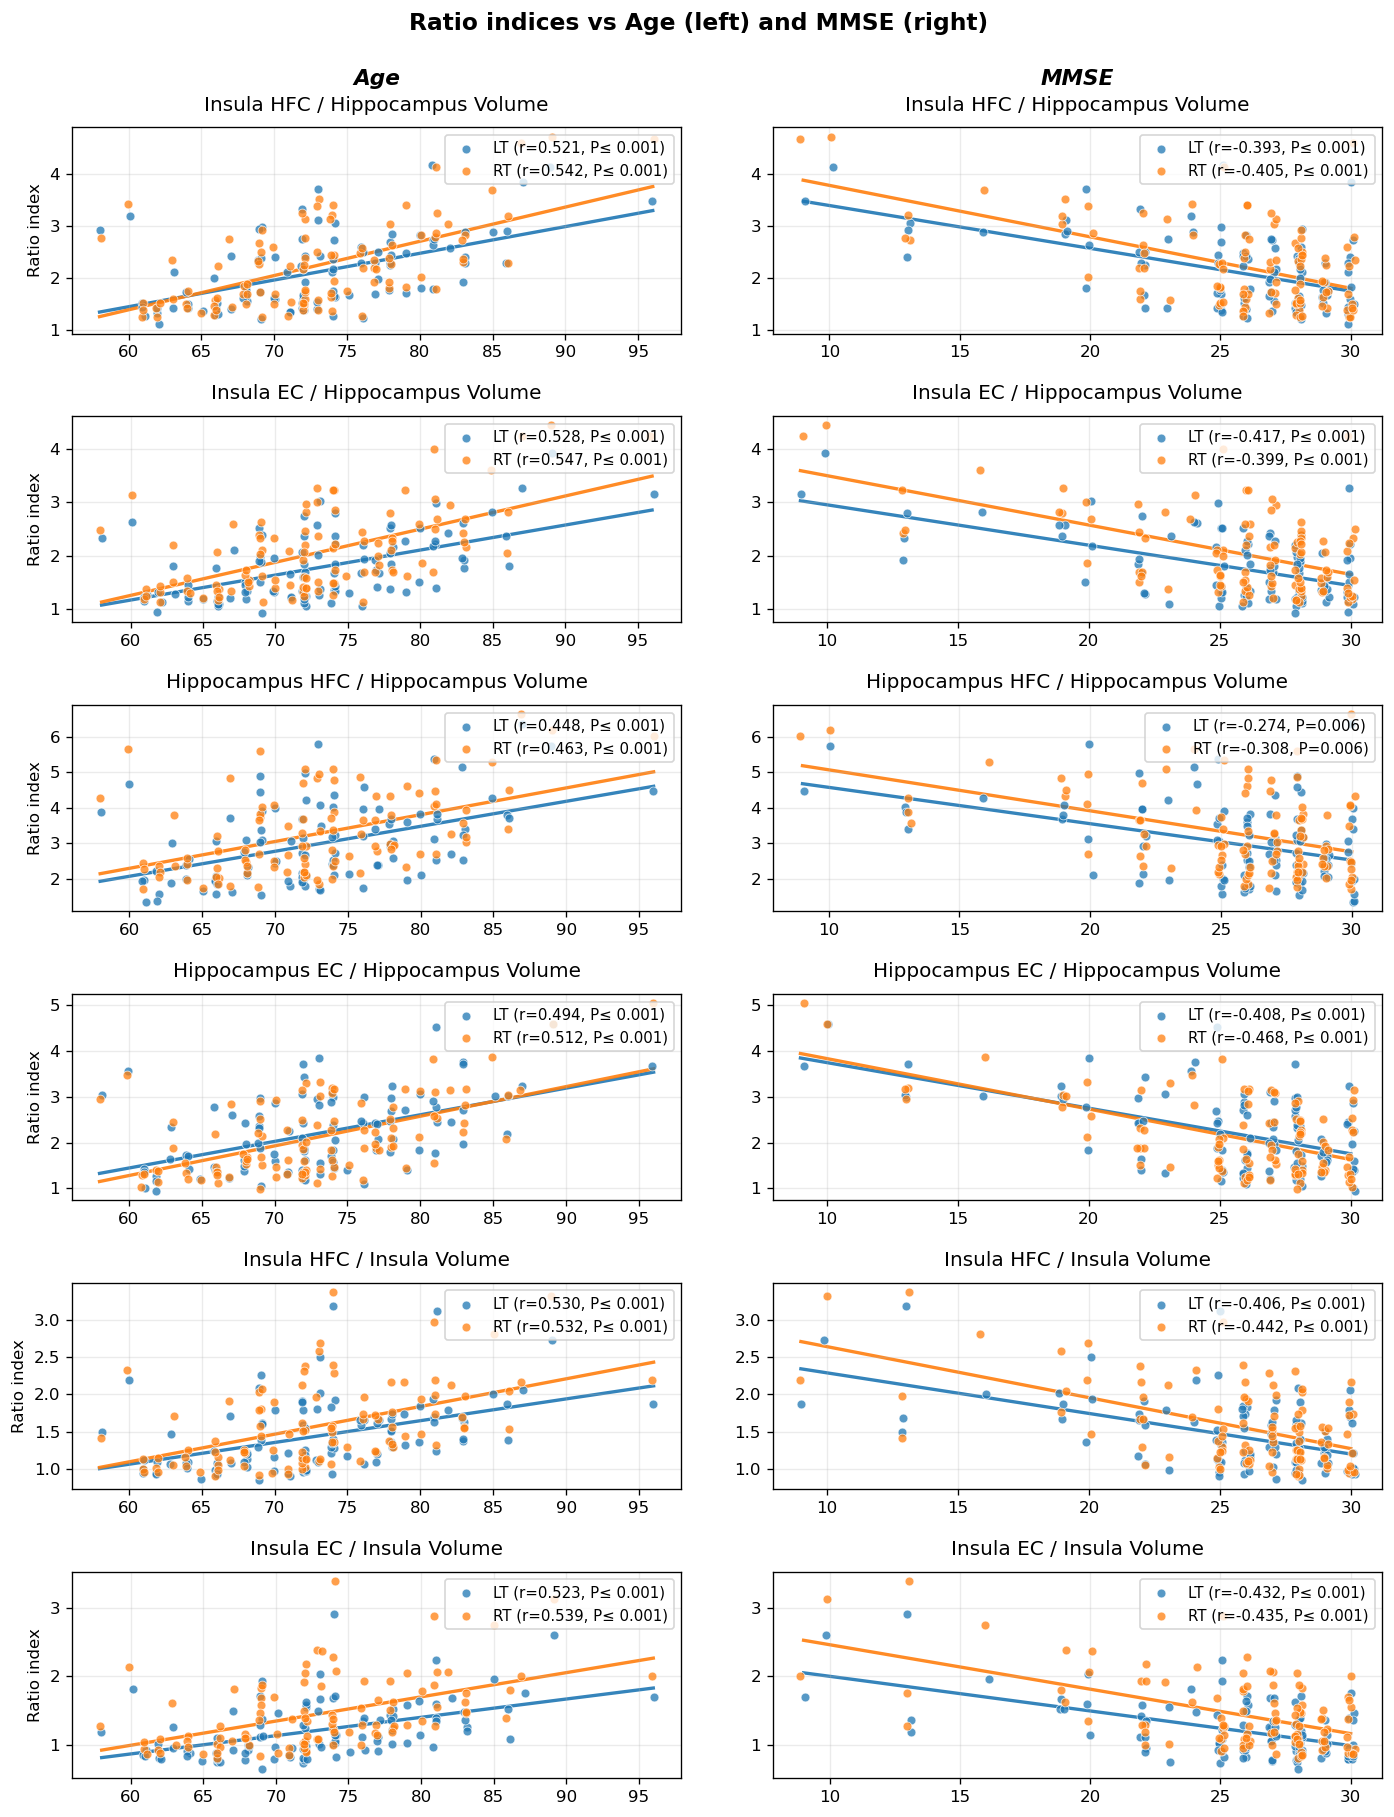

In [120]:
fig, axes = plot_ratio_age_mmse_overlay(
    df,
    figsize=(12, 16),
    dpi=120,
    savepath=os.path.join(base, "Ratio_Age_MMSE_overlay.pdf")  # 예: os.path.join(base, "Ratio_Age_MMSE_overlay.pdf")
)